In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.lattice_surgery.circuit import surgery_circuit
import pickle

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

In [81]:
test_circuit = surgery_circuit(distance = 3, target_state_init="X+", control_state_init="X-", 
                               flow_observable = "X -> XX", noise_measure_flip = 0.1)
test_circuit.detector_error_model()

stim.DetectorErrorModel('''
    error(0.1) D0 D12
    error(0.1) D1 D13
    error(0.1) D2 D14
    error(0.1) D3 D15
    error(0.1) D4 D24
    error(0.1) D5 D25
    error(0.1) D6 D26
    error(0.1) D7 D27
    error(0.1) D8 D32
    error(0.1) D9 D33
    error(0.1) D10 D34
    error(0.1) D11 D35
    error(0.1) D12 D36
    error(0.1) D13 D37
    error(0.1) D14 D38
    error(0.1) D15 D39
    error(0.1) D16
    error(0.1) D16 D40
    error(0.1) D17
    error(0.1) D17 D41
    error(0.1) D18
    error(0.1) D18 D42
    error(0.1) D19
    error(0.1) D19 D43
    error(0.1) D20
    error(0.1) D20 D44
    error(0.1) D21
    error(0.1) D21 D45
    error(0.1) D22
    error(0.1) D22 D46
    error(0.1) D23
    error(0.1) D23 D47
    error(0.1) D24 D48
    error(0.1) D25 D49
    error(0.1) D26 D50
    error(0.1) D27 D51
    error(0.1) D28
    error(0.1) D28 D52
    error(0.1) D29
    error(0.1) D29 D53
    error(0.1) D30
    error(0.1) D30 D54
    error(0.1) D31
    error(0.1) D31 D55
    error(0.1) D32

In [70]:
task_noisy = [sinter.Task(
    circuit = surgery_circuit(
        distance = d, 
        target_state_init ="Z0", 
        control_state_init ="Z1",
        flow_observable = "Z -> Z",
        noise_after_clifford_depol = noise),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.2, 0.25, 0.3]
    for d in [3,5]
    ]

stats_noisy : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10_000,
    print_progress=True
)

Starting 8 workers...
24 tasks left:
  workers    decoder eta shots_left errors_left json_metadata      
        1 pymatching   ?    1000000       10000 p=0.001,distance=3 
        1 pymatching   ?    1000000       10000 p=0.001,distance=5 
        1 pymatching <1m     998703        9985 p=0.0015,distance=3
        1 pymatching   ?    1000000       10000 p=0.0015,distance=5
        1 pymatching   ?    1000000       10000 p=0.002,distance=3 
        1 pymatching   ?    1000000       10000 p=0.002,distance=5 
        1 pymatching   ?    1000000       10000 p=0.0025,distance=3
        1 pymatching   ?    1000000       10000 p=0.0025,distance=5
        0 pymatching ?·∞    1000000       10000 p=0.005,distance=3 
        0 pymatching ?·∞    1000000       10000 p=0.005,distance=5 
        0 pymatching ?·∞    1000000       10000 p=0.01,distance=3  
        0 pymatching ?·∞    1000000       10000 p=0.01,distance=5  
        0 pymatching ?·∞    1000000       10000 p=0.015,distance=3 
        0 p

In [10]:
#Dumping Stats with pickle:
with open("lattice_surgery_measurement_noise_lite.pkl", "wb") as file:
    pickle.dump(stats_noisy, file)

In [ ]:
"""#Loading Stats with pickle
with open("lattice_surgery_measurement_noise.pkl", "rb") as file:
    complete_stats = pickle.load(file)"""

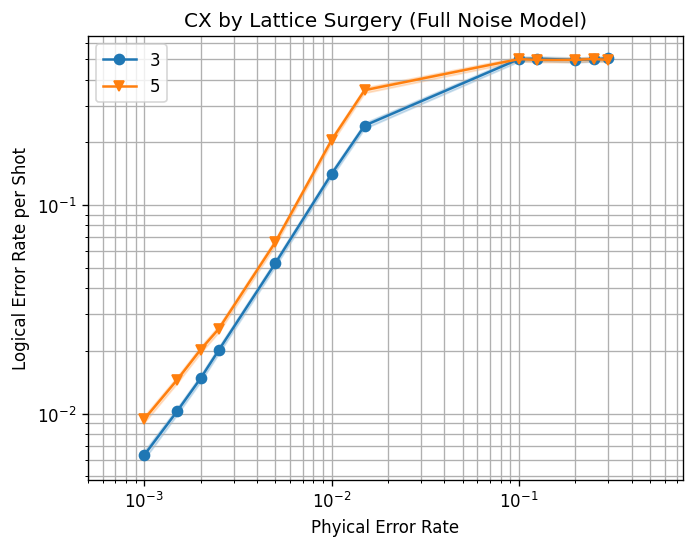

In [74]:
fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance']
)
ax.loglog()
ax.set_xlim(5e-4, 0.75)
ax.set_title("CX by Lattice Surgery (Full Noise Model)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger